# Clustering states by poll profile

Grouping all 145 state-year rows by their poll numbers alone, no
outcome label involved, then checking how well the clusters split by
actual result.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open('data/model_data.pkl', 'rb') as f:
    d = pickle.load(f)
df = pd.concat([d['train'], d['test']]).reset_index(drop = True)
features = ['Rasmussen', 'SurveyUSA', 'PropR', 'DiffCount']
X = df[features]
X.shape

(145, 4)

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score

X_scaled = StandardScaler().fit_transform(X)

K = 3
kmeans = KMeans(n_clusters = K, n_init = 10, random_state = 42)
kmeans_labels = kmeans.fit_predict(X_scaled)

gmm = GaussianMixture(n_components = K, random_state = 42, n_init = 3)
gmm_labels = gmm.fit_predict(X_scaled)

print('KMeans silhouette:', silhouette_score(X_scaled, kmeans_labels))
print('KMeans vs true outcome (ARI):', adjusted_rand_score(df.Republican, kmeans_labels))
print('KMeans vs GMM (ARI):', adjusted_rand_score(kmeans_labels, gmm_labels))

KMeans silhouette: 0.5674118064101951
KMeans vs true outcome (ARI): 0.7653222191516004
KMeans vs GMM (ARI): 0.5847202333344509


In [3]:
profile = df.assign(cluster = kmeans_labels)
cluster_summary = profile.groupby('cluster').agg(
    n = ('Republican', 'size'),
    republican_share = ('Republican', 'mean'),
    mean_diffcount = ('DiffCount', 'mean'),
).round(3)
cluster_summary

,n,republican_share,mean_diffcount
cluster,,,
0,55,0.000,-7.709
1,78,0.949,3.654
2,12,0.000,-3.750


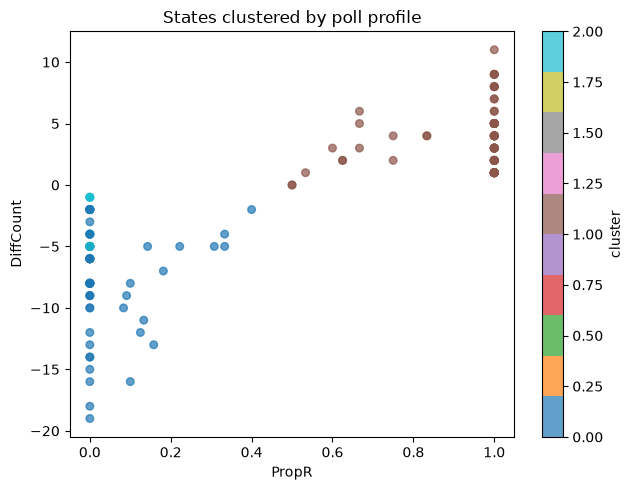

In [4]:
fig, ax = plt.subplots(figsize = (6.5, 5))
sc = ax.scatter(df.PropR, df.DiffCount, c = kmeans_labels, cmap = 'tab10', s = 30, alpha = 0.7)
ax.set_xlabel('PropR'); ax.set_ylabel('DiffCount')
ax.set_title('States clustered by poll profile')
plt.colorbar(sc, ax = ax, label = 'cluster')
plt.tight_layout()
plt.savefig('outputs/cluster_scatter.png', dpi = 120)
plt.show()

Strong agreement here, adjusted Rand index 0.77 between the unsupervised
clusters and the real election outcome, and a silhouette score of 0.57
that says the clusters themselves are well separated, not a forced fit.
Two of the three clusters are entirely Democrat states (0% Republican
share) and one is almost entirely Republican (94.9%), poll numbers
alone, with no outcome label in sight, sort states into groups that
line up closely with what actually happened. That's a reassuring
sanity check on the polling data itself, not just the supervised
models built on top of it.